# **I. Environment setup**

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Global data path
DATA_ROOT = "/mnt/d"
TRAIN_PATH = f"{DATA_ROOT}/train"
TEST_PATH = f"{DATA_ROOT}/test"

print(f"Training datasets: {os.listdir(TRAIN_PATH)}")
print(f"Testing dataset: {os.listdir(TEST_PATH)}")

Training datasets: ['PolarPS', 'hdlong-complexv1']
Testing dataset: ['DiLiGenT']


# **II. Dataset: hdlong-complexv1**

In [8]:
def read_exr(img_path: str) -> np.array:
    img = cv2.imread(img_path, cv2.IMREAD_ANYCOLOR | cv2.IMREAD_ANYDEPTH)
    if img is None:
        print(f"Failed to load image at {img_path}. ")
    else:
        print(f"Success! Image shape: {img.shape}, Data type: {img.dtype}")
    return img

## **1. Dataset structure**

* The dataset consists of several scenes.
* In each scene, there are 10 camera directories with six configuration files.
* In each camera directory, there are binary mask, depth map, surface normal groundtruths local_normal and global_normal (preferably local_normal), 20 point-light images, 20 directional light images, with 10 images in environment light.

In [9]:
# Scenes
!ls /mnt/d/train/hdlong-complexv1/

CaveCrystal01@fabric_159_basecolor-1K
blob01-uv@1K-bark_14_Dif
bone-cookie-001@metalplate_4_ambientocclusion-1K


In [10]:
# Scene data
!tree /mnt/d/train/hdlong-complexv1/CaveCrystal01@fabric_159_basecolor-1K

/mnt/d/train/hdlong-complexv1/CaveCrystal01@fabric_159_basecolor-1K
├── cam_00001
│   ├── binary_mask.exr
│   ├── depth_map.exr
│   ├── dir_light_00001.exr
│   ├── dir_light_00002.exr
│   ├── dir_light_00003.exr
│   ├── dir_light_00004.exr
│   ├── dir_light_00005.exr
│   ├── dir_light_00006.exr
│   ├── dir_light_00007.exr
│   ├── dir_light_00008.exr
│   ├── dir_light_00009.exr
│   ├── dir_light_00010.exr
│   ├── dir_light_00011.exr
│   ├── dir_light_00012.exr
│   ├── dir_light_00013.exr
│   ├── dir_light_00014.exr
│   ├── dir_light_00015.exr
│   ├── dir_light_00016.exr
│   ├── dir_light_00017.exr
│   ├── dir_light_00018.exr
│   ├── dir_light_00019.exr
│   ├── dir_light_00020.exr
│   ├── env_light_00001.exr
│   ├── env_light_00002.exr
│   ├── env_light_00003.exr
│   ├── env_light_00004.exr
│   ├── env_light_00005.exr
│   ├── env_light_00006.exr
│   ├── env_light_00007.exr
│   ├── env_light_00008.exr
│   ├── env_light_00009.exr
│   ├── env_light_00010.exr
│   ├── global_normal.exr
│   ├─

In [11]:
TRIAL_SCENE_PATH = f"{TRAIN_PATH}//hdlong-complexv1/CaveCrystal01@fabric_159_basecolor-1K"

## **2. Dataset contents**

### **2.1. Configuration files**

In [12]:
# We care mostly about light_means.config, which will be used to normalize the point-light, directional light, and environment light images.
light_means = {}

with open(f"{TRIAL_SCENE_PATH}/light_means.config", "r") as f:
    for line in f:
        key, value = line.strip().split()
        light_means[key] = float(value)

print(light_means) 

{'dir_mean': 0.0485684871673584, 'point_mean': 0.0009296800708398223, 'env_mean': 0.16472041606903076}


### **2.2. Binary mask**

In [13]:
CAM_PATH = f"{TRIAL_SCENE_PATH}/cam_00001"

In [14]:
# Read the binary mask
binary_mask_path = f"{CAM_PATH}/binary_mask.exr"
binary_mask = read_exr(binary_mask_path)

# Check its content
unique_values = np.unique(binary_mask)
print(f"{len(unique_values)} unique values in mask:", unique_values)

# Clean the mask
clean_mask = (binary_mask >= 0.5).astype(np.float32)
is_strictly_binary = np.all((clean_mask == 0) | (clean_mask == 1))
print("Contains ONLY 0 and 1:", is_strictly_binary)

Success! Image shape: (256, 256), Data type: float32
2423 unique values in mask: [0.0000000e+00 3.9356056e-13 1.4091740e-11 ... 1.0000000e+00 1.0000001e+00
 1.0000002e+00]
Contains ONLY 0 and 1: True


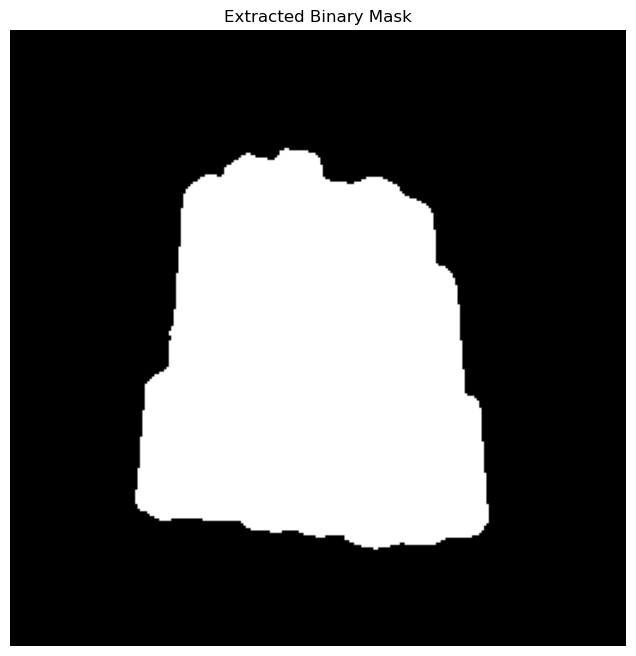

In [21]:
plt.figure(figsize=(8, 8))
plt.imshow(clean_mask, cmap='gray')  # cmap='gray' forces it to render as black and white
plt.axis('off')                       # Hides the coordinate axes for a clean image
plt.title("Extracted Binary Mask")
plt.show()

### **2.3. Rendered images**
Rendered images are the input to the model. They are created as a combination of a point light image, a directional light image, and an environment light image for complexity.

In [15]:
# Randomly select the component images
pnt_img = read_exr(f"{CAM_PATH}/point_light_00003.exr")
dir_img = read_exr(f"{CAM_PATH}/dir_light_00003.exr")
env_img = read_exr(f"{CAM_PATH}/env_light_00003.exr")

# Normalize the component images
pnt_img_normalized = pnt_img / light_means.get("point_mean", 0)
dir_img_normalized = dir_img / light_means.get("dir_mean", 0)
env_img_normalized = env_img / light_means.get("env_mean", 0)

# Apply the mask
pnt_img_ready = pnt_img_normalized * clean_mask[..., None]
dir_img_ready = dir_img_normalized * clean_mask[..., None]
env_img_ready = env_img_normalized * clean_mask[..., None]

Success! Image shape: (256, 256, 3), Data type: float32
Success! Image shape: (256, 256, 3), Data type: float32
Success! Image shape: (256, 256, 3), Data type: float32


In [26]:
# Combining the three images for the final rendered image
alpha, beta, gamma = np.random.dirichlet(np.ones(3), size=1)[0]

print(f"Weights: Point = {alpha:.3f}, Dir = {beta:.3f}, Env = {gamma:.3f}")
print(f"Total Sum: {alpha + beta + gamma:.1f}")

# Create the final image
final_img = (alpha * pnt_img_ready) + (beta * dir_img_ready) + (gamma * env_img_ready)

print(f"Max pixel value in final_img: {final_img.max()}")
print(f"Min pixel value in final_img: {final_img.min()}")

Weights: Point = 0.123, Dir = 0.258, Env = 0.619
Total Sum: 1.0
Max pixel value in final_img: 9.916793061660869
Min pixel value in final_img: 0.0


### **2.4. Rendered images summary**
* **Step 1**: Randomly select a set of scenes
* **Step 2**: For each scence, randomly select a camera
* **Step 3**: For the selected camera, randomly choose a point light image, a directional light image, and an environment light image.
* **Step 4**: Randomly select $\alpha$, $\beta$, $\gamma$ such that $\alpha, \beta, \gamma > 0; \alpha + \beta + \gamma = 1$. Then use these as weights to generate the rendered image.

**NOTE**: Each scene will have 10 images. It is decided that one camera/scene only. Therefore, we have two options:
* $1^{st}$ option: Repeat **Step 3** and **Step 4** 10 times
* $2^{nd}$ option: Repeat **Step 4** 10 times.

I would opt for the $1^{st}$ option as it would increase the lighting condition complexity for the rendered images. What do you think?

# **III. Dataset: PolarPS**

## **1. Dataset structure**

* The dataset consists of several scenes.
* In each scene, we have the groundtruth (normal.exr) and a directory containing 32 lighting directions.
* Each lighting direction contains one image.

In [17]:
# Scenes
!ls /mnt/d/train/PolarPS/

3DBread002_HQ-4K-JPG_x_-9_y_61@statue-ornaments-004_x_-29_y_309@bottle-019_x_-8_y_317
3DBread004_HQ-4K-JPG_x_-7_y_173@duck-toy-001_x_-52_y_318@3DBread011_HQ-4K-JPG_x_-25_y_328


In [18]:
# Scene data
!tree /mnt/d/train/PolarPS/3DBread004_HQ-4K-JPG_x_-7_y_173@duck-toy-001_x_-52_y_318@3DBread011_HQ-4K-JPG_x_-25_y_328

/mnt/d/train/PolarPS/3DBread004_HQ-4K-JPG_x_-7_y_173@duck-toy-001_x_-52_y_318@3DBread011_HQ-4K-JPG_x_-25_y_328
├── normal.exr
└── woodparquet_76_basecolor-1K#Wood082B_1K-JPG_Color#woodplank_41_BaseColor-1K
    ├── light-01
    │   └── S0.exr
    ├── light-02
    │   └── S0.exr
    ├── light-03
    │   └── S0.exr
    ├── light-04
    │   └── S0.exr
    ├── light-05
    │   └── S0.exr
    ├── light-06
    │   └── S0.exr
    ├── light-07
    │   └── S0.exr
    ├── light-08
    │   └── S0.exr
    ├── light-09
    │   └── S0.exr
    ├── light-10
    │   └── S0.exr
    ├── light-11
    │   └── S0.exr
    ├── light-12
    │   └── S0.exr
    ├── light-13
    │   └── S0.exr
    ├── light-14
    │   └── S0.exr
    ├── light-15
    │   └── S0.exr
    ├── light-16
    │   └── S0.exr
    ├── light-17
    │   └── S0.exr
    ├── light-18
    │   └── S0.exr
    ├── light-19
    │   └── S0.exr
    ├── light-20
    │   └── S0.exr
    ├── light-21
    │   └── S0.exr
    ├── light-22
    │   └── S0.exr
  

In [19]:
Polar_TRIAL_SCENE_PATH = f"{TRAIN_PATH}/PolarPS/3DBread004_HQ-4K-JPG_x_-7_y_173@duck-toy-001_x_-52_y_318@3DBread011_HQ-4K-JPG_x_-25_y_328"

## **2. Dataset contents**

### **2.1. Extract mask from <code>normal.exr</code>**

Success! Image shape: (512, 512, 3), Data type: float32
Binary mask shape: (512, 512)


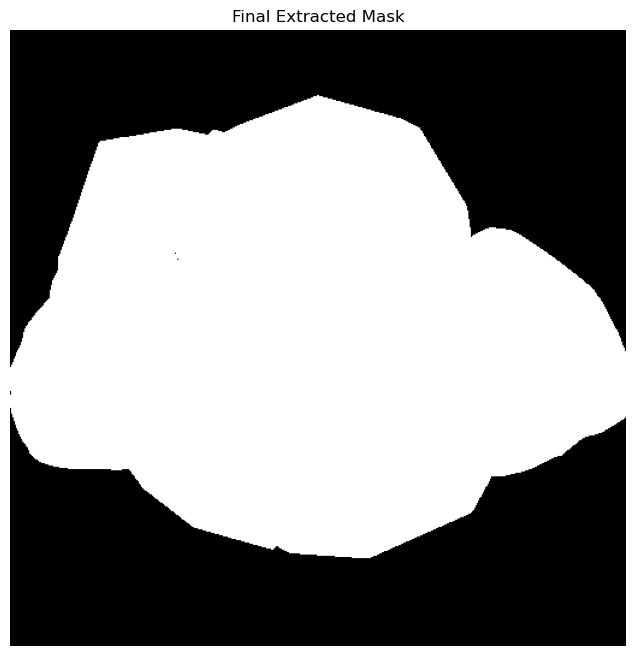

In [24]:
normals = read_exr(f"{Polar_TRIAL_SCENE_PATH}/normal.exr")
normals_vectors = (normals - 0.5) * 2.0

# 2. Calculate the vector magnitude (length)
# The background will now have a length of 0. The object will have a length around 1.
magnitude = np.linalg.norm(normals_vectors, axis=-1)

# 3. Extract the binary mask
polar_binary_mask = (magnitude > 0.5).astype(np.float32)
print(f"Binary mask shape: {polar_binary_mask.shape}")

# 4. Show the result
plt.figure(figsize=(8, 8))
plt.imshow(polar_binary_mask, cmap='gray')
plt.axis('off')
plt.title("Final Extracted Mask")
plt.show()

### **2.2. Rendered images**

In [27]:
raw_img = read_exr(f"{Polar_TRIAL_SCENE_PATH}/woodparquet_76_basecolor-1K#Wood082B_1K-JPG_Color#woodplank_41_BaseColor-1K/light-01/S0.exr")
final_img = raw_img * polar_binary_mask[..., None]

print(f"Max pixel value in final_img: {final_img.max()}")
print(f"Min pixel value in final_img: {final_img.min()}")

Success! Image shape: (512, 512, 3), Data type: float32
Max pixel value in final_img: 2.8198330402374268
Min pixel value in final_img: -1.9321649233461358e-05


### **2.3. Rendered images summary**
* **Step 1**: Randomly select a set of scenes
* **Step 2**: For each scene, randomly select 10 lighting directions from the only sub-directory.
* **Step 2.5**: For each scene, use <code>normal.exr</code> to extract the binary mask.

**NOTE**: We will combine these two datasets into one dataset used for training. As a result, we will still opt for 10 images/scene. However, the input shape SHOULD BE the same, regardless of what dataset they come from. I supposed we have to upsample the final_img from hdlong-complexv1 from $(256, 256) \rightarrow (512, 512)$.